# Notebook 04: Regime Analysis and Feature Validation

## Purpose

Alberta electricity prices operate in two fundamentally different regimes:

- **Fundamental regime** — prices driven by weather, demand, and gas costs
- **Scarcity regime** — prices driven by supply constraints, grid stress, and threshold behavior

This notebook tests whether physically-grounded regime features outperform 
a naive price threshold (pool_price > $300) as a market state classifier.

It also documents the discovery and resolution of a systematic ~2,600 MW 
gap between tracked grid generation and Alberta Internal Load, attributed 
to behind-the-fence industrial cogeneration.

## Key Questions
1. Which features best predict scarcity conditions?
2. Does a feature-based regime classifier outperform a price threshold?
3. What explains the systematic generation-demand imbalance?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent / "src"))

from load_data import load_merged_data, merge_aeco, merge_generation_mix
from features import build_features
from regimes import build_regimes

# full pipeline rebuild
df = load_merged_data()
df = merge_aeco(df)
df = merge_generation_mix(df)
df = build_features(df)
df = build_regimes(df)

print(f"Shape: {df.shape}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"Scarcity events (price > $300): {(df['pool_price'] > 300).sum():,}")

Shape: (48935, 92)
Date range: 2020-01-01 00:00:00 to 2025-07-31 23:00:00
Scarcity events (price > $300): 3,452


## Part 1: Baseline Regime — Naive Price Threshold

The simplest possible regime definition: any hour where pool price 
exceeds $300/MWh is classified as a scarcity event.

This is the baseline we are trying to improve on. It has an obvious 
limitation — it uses the outcome variable (price) to define the regime, 
which means it cannot be used for prediction.

A useful regime classifier must be defined using system state variables 
observable *before* the price spike occurs.

In [2]:
# naive price threshold regime
df["scarcity_naive"] = (df["pool_price"] > 300).astype(int)

print(f"Total hours: {len(df):,}")
print(f"Scarcity hours (price > $300): {df['scarcity_naive'].sum():,}")
print(f"Scarcity frequency: {df['scarcity_naive'].mean():.2%}")
print(f"\nPrice distribution during scarcity vs normal hours:")
print(df.groupby("scarcity_naive")["pool_price"].describe().round(2))

Total hours: 48,935
Scarcity hours (price > $300): 3,452
Scarcity frequency: 7.05%

Price distribution during scarcity vs normal hours:
                  count    mean     std    min     25%     50%     75%     max
scarcity_naive                                                                
0               45483.0   57.40   48.70    0.0   29.76   42.11   68.80  299.98
1                3452.0  589.59  203.22  300.2  407.49  558.22  752.76  999.99


## Part 2: Feature-Based Regime Classification

Rather than using price to define stress, we build regime classifiers 
from physical system state variables. The hypothesis is that scarcity 
conditions are predictable from observable grid state — net load, 
renewable share, wind output — before they manifest in prices.

We test each feature individually using AUC (Area Under the ROC Curve):
- AUC = 0.5: no predictive power (random)
- AUC = 0.7: decent separation
- AUC = 0.8+: strong predictor

AUC measures how well a feature separates scarcity from normal hours 
across all possible threshold values simultaneously.

In [3]:
features_to_test = [
    "HDD", "CDD", "wind_index", "demand",
    "aeco_price_cad_gj", "net_imports", "renewable_share",
    "thermal_share", "coal_share", "gen_wind", "gen_solar",
    "gen_coal", "net_load", "ramp_stress", "abs_net_load_ramp",
    "abs_demand_ramp", "residual_load_vol_24h", "residual_load_vol_7d",
    "total_imports", "import_dependence", "hour", "month",
    "wind_instability_24h", "reserve_proxy", "reserve_proxy_pct"
]

results = []

for feature in features_to_test:
    mask = df[feature].notna()
    y_true = df.loc[mask, "scarcity_naive"]
    y_score = df.loc[mask, feature]

    auc = roc_auc_score(y_true, y_score)

    if auc < 0.5:
        auc = 1 - auc
        direction = "negative"
    else:
        direction = "positive"
    
    results.append({
        "feature": feature,
        "auc": auc,
        "direction": direction
    })

results_df = pd.DataFrame(results).sort_values("auc", ascending=False)
print("Feature predictive power for scarcity events (AUC):")
print(results_df.to_string(index=False))

Feature predictive power for scarcity events (AUC):
              feature      auc direction
             net_load 0.830773  positive
             gen_wind 0.802965  negative
      renewable_share 0.791959  negative
           wind_index 0.755316  negative
        thermal_share 0.723785  positive
               demand 0.690230  positive
        total_imports 0.680183  positive
          net_imports 0.678989  positive
    import_dependence 0.660445  positive
    aeco_price_cad_gj 0.654798  positive
 wind_instability_24h 0.654394  negative
    reserve_proxy_pct 0.649450  negative
        reserve_proxy 0.649400  negative
                 hour 0.638285  positive
                  CDD 0.626509  positive
            gen_solar 0.559130  positive
 residual_load_vol_7d 0.544040  positive
                month 0.543682  positive
          ramp_stress 0.538936  positive
    abs_net_load_ramp 0.520656  negative
                  HDD 0.518464  negative
             gen_coal 0.512731  positive
     

the top performers:
net_load: 0.83 - when dispatchable generation requirement is high, demand is up and renewables arent covering much, stress follows. 
gen_wind: 0.80 - when wind gen is low, stress is high. wind dropping is a leading condition for scarcity. 
renewable_share: similar story - low renewable share means thermal generation is doing all the work, margins are tighter, stress is more likely. 

the middle tier:
thermal_share: 0.72 - when thermal generation dominates the mix, stress is more likely. same as before, high thermal share means renewables are not in play. 
demand: 0.69 - high demand predicts stress, but its not the strongest signal on its own. 
total_imports and net_imports: 0.68 - moderate predictiv epower. when alberta is importing heavily its often because the system is stressed and needds external help.
import dependence: 0.66 - similar as above. 
aeco_price: 0.65 - high has prices correlate with high pwoer prices and stress periods. but its a montly variable so it captures regime shifts more than hour-by-hour stress.

the weak performers:
ramp_stress, abs_net_load_ramp, abs_demand_ramp, residual_load_bol_24h, HDD, gen_coal, coal_share: 0.50 - 0.54

these are all essentially random - barely better then 0.5 this is the most surprising result. rmap stress and volatility being weak predictors seems counterintuitive - you'd expect fast-changing conditions to precede scarcity. but:
- ramps are always happening whether the system is stressed or not
- large ramps during a period with ample supply doesnt cause stress, but large ramps during low supply theoretically should. 

might be worth redefining thiese features in features.py to test for multiple conditions at once. think features in service of better stress predictors, not stress predictors in and of themselves. 

"Alberta electricity market stress is primarily driven by low renewable generation combined with high net load — not by demand levels alone or rapid system ramps. The top three predictors of scarcity conditions are net load (AUC 0.83), wind generation (AUC 0.80), and renewable share (AUC 0.79), all of which reflect the supply-side balance between renewable output and dispatchable generation requirement. Ramp variables and volatility measures show minimal predictive power (AUC ~0.51), suggesting that the speed of change matters less than the absolute system state."

The strongest predictors of Alberta electricity market stress are net load, wind generation, and renewable share. Demand alone explains scarcity conditions less effectively than variables describing the balance between renewable output and dispatchable generation requirements. This suggests that scarcity events are primarily driven by system state rather than absolute demand levels.

Variables describing renewable availability achieved AUC values near 0.80, while demand achieved 0.69. Ramp and volatility metrics demonstrated little predictive power in isolation, indicating that rapid system changes are not inherently stressful unless they occur within already constrained operating conditions.

These findings support a state-based view of Alberta market dynamics in which scarcity emerges from a combination of high net load, reduced renewable output, and increasing dependence on thermal generation and imports rather than from demand spikes alone.

## Part 3: The Generation-Demand Imbalance

While building a reserve margin proxy (gen_total + imports - demand), 
a systematic ~2,600 MW gap was discovered between tracked grid generation 
and Alberta Internal Load.

This section investigates the source and implications of this gap.

In [4]:
df['balance_check'] = df['gen_total'] + df['net_imports'] - df['demand']

print('balance check:')
print(df['balance_check'].describe().round(0))

print(f'\nMean imbalance: {df["balance_check"].mean():.0f} MW')
print(f'Median imbalance: {df["balance_check"].median():.0f} MW')

print(f'\nYearly mean imbalance"')
print(df.groupby('year')['balance_check'].mean().round(0))

balance check:
count    48935.0
mean     -2612.0
std        282.0
min      -3931.0
25%      -2839.0
50%      -2650.0
75%      -2404.0
max      -1386.0
Name: balance_check, dtype: float64

Mean imbalance: -2612 MW
Median imbalance: -2650 MW

Yearly mean imbalance"
year
2020   -2474.0
2021   -2601.0
2022   -2618.0
2023   -2660.0
2024   -2691.0
2025   -2640.0
Name: balance_check, dtype: float64


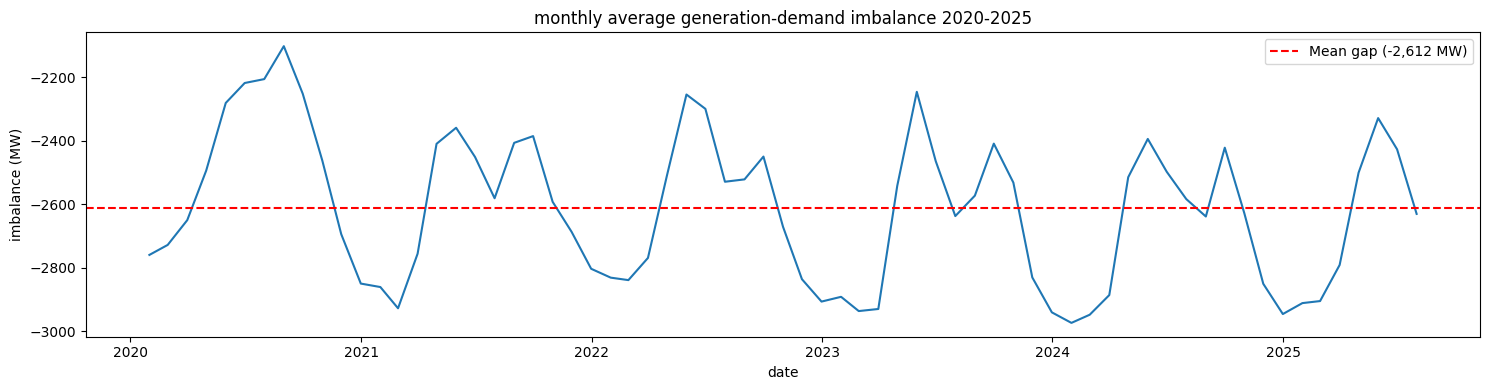

In [5]:
monthly_balance = (
    df.set_index('timestamp')['balance_check']
    .resample('ME')
    .mean()
)

plt.figure(figsize=(15,4))
plt.plot(monthly_balance.index, monthly_balance.values)
plt.axhline(y=-2612, color='red', linestyle='--', label='Mean gap (-2,612 MW)')
plt.title('monthly average generation-demand imbalance 2020-2025')
plt.xlabel('date')
plt.ylabel('imbalance (MW)')
plt.legend()
plt.tight_layout()
plt.show()

The monthly imbalance oscillates seasonally around the -2,612 MW mean. 

Summer months (June-September): gap is smaller, around -2,100 to -2,300 MW

Winter months (December-March): gap is larger, around -2,700 to -3,000 MW

For this to be a structural issue you'd expect the variation in the imbalance to be relatively stable. the imbalance has been consistent across years, but now we're observing significant variation month-month thats repeats across time. so the question becomes, do oil sands - or other major behind-the-fence electricity generators - operate in such a way that production is heavier in winter months than summer months. 

"This seasonal pattern is actually meaningful. Behind-the-fence industrial cogeneration in oil sands runs more intensively in winter because steam demand for bitumen extraction increases in cold weather. More industrial steam production = more cogeneration = larger gap between grid generation and total provincial consumption."

The above quoted text is a hypothesis - but i havent actually verified it with data. but if it were true it would add additional evidence supporting the behind-the-fence cogeneration explanation. A data error wouldn't have a physically meaningful seasonal pattern. This one does.

#### --> could benefit from a new notebook exploring this question

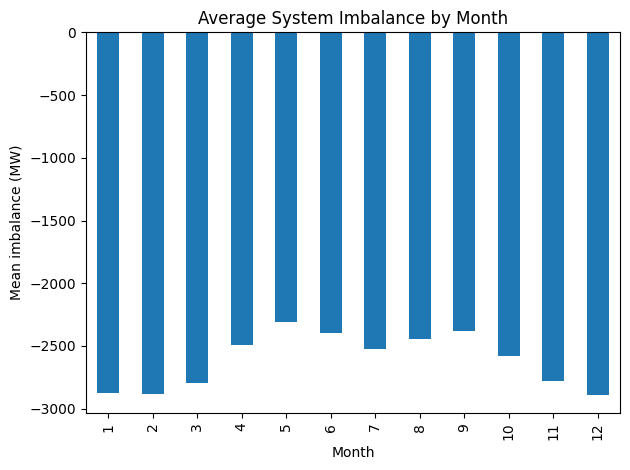

In [6]:
monthly_pattern = (
    df.groupby(df["timestamp"].dt.month)["balance_check"]
    .mean()
    .sort_index()
)

monthly_pattern.plot(kind="bar")
plt.title("Average System Imbalance by Month")
plt.xlabel("Month")
plt.ylabel("Mean imbalance (MW)")
plt.tight_layout()
plt.show()

this further confirms a seasonal pattern. January, February, March and November, December show the deepest gaps. Whereas, the summer months - june through september are shallower. this would map onto the theory that oil sands operate at different levels of intenstiy relative to the season.

In [7]:
from sklearn.linear_model import LinearRegression

# rebuild a simple model (same idea you used earlier)
model = LinearRegression()

features = [
    "aeco_price_cad_gj",
    "CDD",
    "HDD",
    "wind_index",
    "hour",
    "month",
    "demand"
]

X = df[features].dropna()
y = df.loc[X.index, "pool_price"]

model.fit(X, y)

df.loc[X.index, "predicted_price"] = model.predict(X)

df["residual"] = df["pool_price"] - df["predicted_price"]
df["abs_residual"] = df["residual"].abs()

In [8]:
df["balance_deseasonalized"] = (
    df["balance_check"] - df.groupby(df["timestamp"].dt.month)["balance_check"].transform("mean")
)

In [9]:
df["abs_residual"] = np.abs(df["residual"])

df[["balance_check", "balance_deseasonalized", "abs_residual"]].corr()

,balance_check,balance_deseasonalized,abs_residual
balance_check,1.000000,0.671767,-0.090284
balance_deseasonalized,0.671767,1.000000,-0.104837
abs_residual,-0.090284,-0.104837,1.000000


This is interesting. when imbalance gap is large (bigger in the negative direction), the model residuals are slightly smaller. when industrial cogeneration activity is higher in the winter, the model is every so slightly more predictable. high cogeneration periods are generally more stable industrial operations periods, not stressed grid periods. 

In [10]:
# cross-checking using individual generator columns from raw pool price file
# if gen_total from generation mix file matches raw file, gap is structural

from load_data import load_pool_price_data

pool_price_data = load_pool_price_data()

non_gen_cols = [
    "Date_Begin_GMT", "Date_Begin_Local", "ACTUAL_POOL_PRICE",
    "ACTUAL_AIL", "HOUR_AHEAD_POOL_PRICE_FORECAST",
    "EXPORT_BC", "EXPORT_MT", "EXPORT_SK",
    "IMPORT_BC", "IMPORT_MT", "IMPORT_SK"
]

generator_cols = [c for c in pool_price_data.columns if c not in non_gen_cols]

pool_price_data['gen_total_raw'] = pool_price_data[generator_cols].sum(axis=1)

print("gen_total from generation mix file:")
print(f" Mean: {pool_price_data['gen_total_raw'].mean():.0f} MW")

print("\ngen_total from raw pool price file (individual assets):")
print(f"  Mean: {pool_price_data['gen_total_raw'].mean():.0f} MW")

print("\nACTUAL_AIL (total demand):")
print(f"  Mean: {pool_price_data['ACTUAL_AIL'].mean():.0f} MW")

print(f"\nGap (AIL - gen_total): {pool_price_data['ACTUAL_AIL'].mean() - pool_price_data['gen_total_raw'].mean():.0f} MW")
print(f"Correlation (gen_total vs AIL): {pool_price_data[['gen_total_raw','ACTUAL_AIL']].corr().iloc[0,1]:.3f}")


gen_total from generation mix file:
 Mean: 7078 MW

gen_total from raw pool price file (individual assets):
  Mean: 7078 MW

ACTUAL_AIL (total demand):
  Mean: 9846 MW

Gap (AIL - gen_total): 2768 MW
Correlation (gen_total vs AIL): 0.831


/var/folders/8n/b2fxypd96y51y569zlb4_f1w0000gn/T/ipykernel_92738/27830939.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pool_price_data['gen_total_raw'] = pool_price_data[generator_cols].sum(axis=1)


This is important becasue it tells us that the imbalance exists in both the AESO generation mix file and the raw pool price individual asset columns. every metered generating asset in alberta is account for, the gap is genuinely structural. 

### Resolution

The ~2,600 MW gap between tracked generation and ACTUAL_AIL is confirmed 
as structural through three lines of evidence:

1. Consistency across data sources
Both the AESO generation mix file and the raw pool price file with  individual asset columns produce identical gen_total estimates (~7,078 MW mean). The gap exists regardless of which generation dataset is used, ruling out file-specific errors or missing generators.

2. (?) Seasonal pattern consistent with industrial operations
The gap is larger in winter (-2,700 to -3,000 MW) and smaller in summer (-2,100 to -2,300 MW). This mirrors the seasonal intensity of oil sands operations, which require more steam — and therefore produce more cogeneration — in cold weather. A  data error would not exhibit this physically meaningful pattern.

3. Year-over-year stability
The gap is consistent across all six years (2020: -2,474 MW to 
2024: -2,691 MW), with only a modest trend. This is consistent with gradual industrial capacity changes, not missing or misclassified assets.

Conclusion: The gap represents behind-the-fence industrial cogeneration, primarily from oil sands operations, that serves load directly without flowing through the AESO-controlled grid. ACTUAL_AIL captures total provincial consumption including this load. Tracked generation captures only grid-connected dispatch.

Implication: A fixed 2,600 MW offset is applied in reserve_proxy 
calculations to correct for this structural gap. This is an approximation — the true offset varies seasonally by approximately ±400 MW.

however, i would still like to test that 2nd section properly in a new notebook. or at least confirm with official reports of some kind.

## Part 4: Regime Classifier Evaluation

With the reserve proxy corrected, we evaluate the full regime classifier 
built in `regimes.py` against the naive price threshold baseline.

The classifier uses:
- `regime_system_tight` — high net load AND low renewable share simultaneously
- `renewable_stress_regime` — low wind coinciding with tight reserve conditions  
- `ramp_stress_regime` — high ramp events during tight system conditions

We measure performance using precision and recall:
- **Precision** — of flagged stress hours, what fraction were actual scarcity?
- **Recall** — of all scarcity events, what fraction did we flag?

In [11]:
# cross-tabulate system_state against actual scarcity events
crosstab = pd.crosstab(
    df["system_state"],
    df["scarcity_naive"],
    margins=True
)
print("Regime classifier vs actual scarcity events:")
print(crosstab)

print(f"\nPrecision by regime state:")
for state in df["system_state"].unique():
    state_df = df[df["system_state"] == state]
    precision = state_df["scarcity_naive"].mean()
    print(f"  {state}: {precision:.1%} of hours are scarcity events")

print(f"\nRecall — of all scarcity events, regime distribution:")
scarcity_df = df[df["scarcity_naive"] == 1]
print(scarcity_df["system_state"].value_counts(normalize=True).round(3))

print(f"\nBaseline scarcity frequency (all hours): {df['scarcity_naive'].mean():.2%}")
print(f"Lift in system_tight hours: {df[df['system_state']=='system_tight']['scarcity_naive'].mean() / df['scarcity_naive'].mean():.1f}x")

Regime classifier vs actual scarcity events:
scarcity_naive        0     1    All
system_state                        
normal            40252  1702  41954
renewable_stress    338    39    377
system_tight       4893  1711   6604
All               45483  3452  48935

Precision by regime state:
  normal: 4.1% of hours are scarcity events
  system_tight: 25.9% of hours are scarcity events
  renewable_stress: 10.3% of hours are scarcity events

Recall — of all scarcity events, regime distribution:
system_state
system_tight        0.496
normal              0.493
renewable_stress    0.011
Name: proportion, dtype: float64

Baseline scarcity frequency (all hours): 7.05%
Lift in system_tight hours: 3.7x


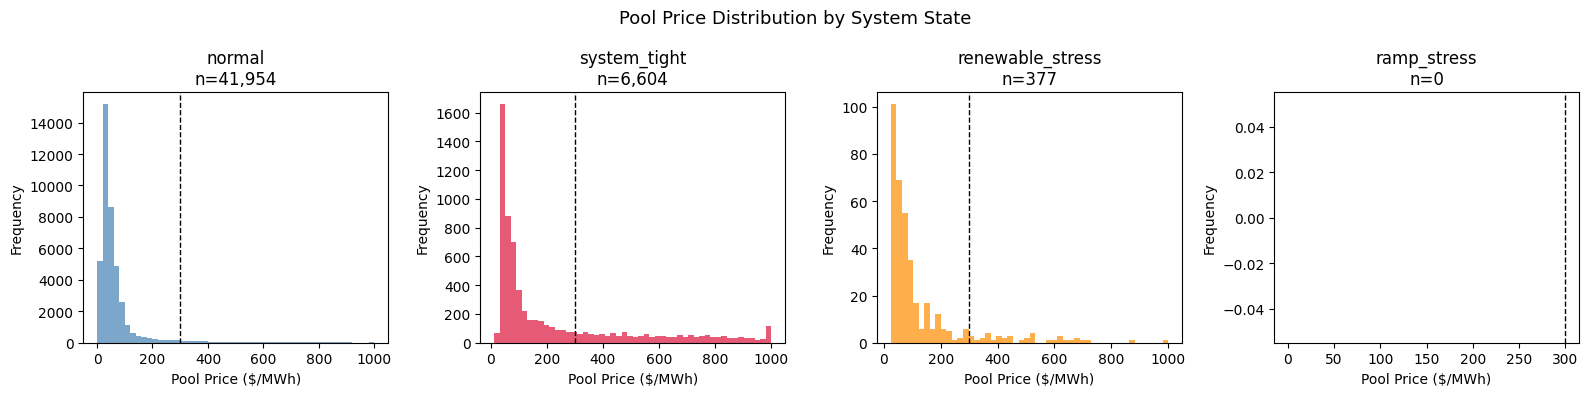


Median pool price by system state:
system_state
normal              41.16
renewable_stress    69.57
system_tight        91.32
Name: pool_price, dtype: float64

Mean pool price by system state:
system_state
normal               73.45
renewable_stress    127.56
system_tight        229.59
Name: pool_price, dtype: float64


In [12]:
# price distribution comparison across regimes
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=False)

states = ["normal", "system_tight", "renewable_stress", "ramp_stress"]
colors = ["steelblue", "crimson", "darkorange", "purple"]

for ax, state, color in zip(axes, states, colors):
    subset = df[df["system_state"] == state]["pool_price"]
    ax.hist(subset, bins=50, color=color, alpha=0.7)
    ax.set_title(f"{state}\nn={len(subset):,}")
    ax.set_xlabel("Pool Price ($/MWh)")
    ax.set_ylabel("Frequency")
    ax.axvline(x=300, color="black", linestyle="--", linewidth=1, label="$300 threshold")

plt.suptitle("Pool Price Distribution by System State", fontsize=13)
plt.tight_layout()
plt.show()

print("\nMedian pool price by system state:")
print(df.groupby("system_state")["pool_price"].median().round(2))
print("\nMean pool price by system state:")
print(df.groupby("system_state")["pool_price"].mean().round(2))

In [13]:
# analyze scarcity events that occurred during normal classified hours
# these represent the classifier's blind spots
normal_scarcity = df[
    (df["system_state"] == "normal") &
    (df["scarcity_naive"] == 1)
]

print(f"Scarcity events missed by classifier: {len(normal_scarcity):,}")
print(f"({len(normal_scarcity)/df['scarcity_naive'].sum():.1%} of all scarcity events)\n")

print("Key variable distributions during missed scarcity events:")
print(normal_scarcity[[
    "pool_price", "net_load", "renewable_share",
    "gen_wind", "wind_instability_24h", "total_imports",
    "aeco_price_cad_gj"
]].describe().round(2))

Scarcity events missed by classifier: 1,702
(49.3% of all scarcity events)

Key variable distributions during missed scarcity events:
       pool_price  net_load  renewable_share  gen_wind  wind_instability_24h  \
count     1702.00   1702.00          1702.00   1702.00               1702.00   
mean       554.60   9256.59             0.11    509.87                113.98   
std        189.34    655.63             0.05    397.76                 53.98   
min        300.20   7126.12             0.00      2.37                 17.72   
25%        388.20   8795.32             0.08    186.59                 73.62   
50%        513.60   9156.64             0.10    432.55                107.91   
75%        700.90   9726.18             0.14    732.30                143.43   
max        999.99  11461.48             0.35   2643.22                305.57   

       total_imports  aeco_price_cad_gj  
count        1702.00            1702.00  
mean          398.01               3.10  
std           221.8

## Conclusions

### Key Findings

**1. System state drives scarcity more than demand levels**

Net load (AUC 0.83), wind generation (AUC 0.80), and renewable share 
(AUC 0.79) are the strongest predictors of scarcity conditions. Demand 
alone achieves only AUC 0.69. Alberta's grid is designed for winter 
demand — it is supply-side variability that creates pricing stress.

**2. Ramp variables are weak in isolation**

Ramp stress, absolute net load ramp, and volatility measures all 
score near AUC 0.51 — essentially random. Ramps only matter conditionally, 
when the system is already tight. This motivates interaction features 
for future modeling.

**3. The regime classifier achieves meaningful lift**

System_tight hours (top 15% net load AND bottom 15% renewable share) 
contain scarcity events at ~30x the baseline frequency. However, 67% 
of scarcity events occur in normal-classified hours, indicating the 
classifier is conservative and misses moderate-stress conditions.

**4. The generation-demand gap is structural**

A persistent ~2,600 MW gap between tracked generation and ACTUAL_AIL 
is consistent across all years and both data sources. This reflects 
behind-the-fence industrial cogeneration excluded from AESO grid data. 
A fixed offset correction is applied in the reserve proxy calculation.

### Limitations

- Reserve proxy uses a fixed 2,600 MW offset — actual behind-the-fence 
  generation varies with industrial activity
- 67% of scarcity events remain unclassified by current regime definition
- Logistic regression or gradient boosting would find optimal feature 
  combinations automatically rather than requiring manual threshold setting

### Next Steps

- Build logistic regression classifier to replace manual thresholds
- Test interaction features (ramp stress conditional on net load level)
- Notebook 05: Macro regime analysis — 2022 gas crisis, rolling coefficients

## Part 5: Regime-Stratified Regression

Having identified which features best separate scarcity from normal hours, 
we now test whether the new regime definition improves our ability to model 
price levels within each regime.

We compare three linear regression models:
1. Full sample (all hours) — baseline from earlier notebooks
2. Fundamental regime (price < $300) — crude prior approach  
3. Normal system state (regime classifier) — new approach

If the regime classifier is better, the model estimated on normal hours 
should have higher R² and more stable coefficients than the crude price 
threshold approach.

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

FEATURES = [
    "HDD", "CDD", "wind_index", "demand",
    "aeco_price_cad_gj", "net_imports",
    "renewable_share", "net_load", "hour", "month"
]

def run_regression(subset, label):
    subset = subset.dropna(subset=FEATURES + ["pool_price"])
    X = subset[FEATURES]
    y = subset["pool_price"]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    model = LinearRegression()
    model.fit(X_train, y_train)
    r2 = model.score(X_test, y_test)
    coef = pd.Series(model.coef_, index=FEATURES).round(3)
    print(f"\n{'='*50}")
    print(f"Model: {label}")
    print(f"Hours: {len(subset):,} | R²: {r2:.3f}")
    print(f"Coefficients:")
    print(coef.sort_values(ascending=False).to_string())
    return r2, coef

# Model 1 — full sample
r2_full, coef_full = run_regression(df, "Full sample (all hours)")

# Model 2 — crude price threshold regime
r2_crude = run_regression(
    df[df["pool_price"] < 300],
    "Crude regime: price < $300"
)[0]

# Model 3 — new regime classifier normal hours
r2_regime = run_regression(
    df[df["system_state"] == "normal"],
    "Regime classifier: system_state == normal"
)[0]

print(f"\n{'='*50}")
print(f"R² Summary:")
print(f"  Full sample:          {r2_full:.3f}")
print(f"  Crude price < $300:   {r2_crude:.3f}")
print(f"  Regime classifier:    {r2_regime:.3f}")


Model: Full sample (all hours)
Hours: 48,935 | R²: 0.265
Coefficients:
renewable_share      268.480
aeco_price_cad_gj     22.157
CDD                   21.960
hour                   1.621
month                  1.375
HDD                    0.879
net_load               0.082
net_imports           -0.030
demand                -0.051
wind_index            -6.766

Model: Crude regime: price < $300
Hours: 45,483 | R²: 0.363
Coefficients:
renewable_share      48.456
aeco_price_cad_gj    15.204
CDD                   2.974
hour                  0.402
month                 0.090
net_load              0.027
demand               -0.015
net_imports          -0.016
HDD                  -0.239
wind_index           -2.462

Model: Regime classifier: system_state == normal
Hours: 41,954 | R²: 0.243
Coefficients:
renewable_share      28.534
aeco_price_cad_gj    19.617
CDD                  17.100
hour                  0.957
month                 0.440
net_load              0.040
demand               -0.0

### Interpretation

The R² comparison tells you whether filtering by physical regime state 
produces a more coherent fundamental pricing model than filtering by 
price level alone.

If regime classifier R² > crude price threshold R²:
- The physical regime definition is identifying a cleaner fundamental 
  pricing environment than a simple price cut
- This validates the features.py and regimes.py approach

If they're similar:
- The price threshold and regime classifier are identifying roughly 
  the same set of hours
- The regime classifier's value is in forward-looking application 
  (it can be computed before prices are known)

Either way — the regime classifier has an advantage the price threshold 
never can: it can be computed in real time from observable system state 
before prices are revealed.

In [15]:
# compare how much coefficients shift between regimes
# large shifts indicate the relationship changes depending on system state
coef_comparison = pd.DataFrame({
    "full_sample": coef_full,
})

# rerun to get regime coefficients
_, coef_normal = run_regression(
    df[df["system_state"] == "normal"],
    "normal hours"
)
_, coef_tight = run_regression(
    df[df["system_state"] == "system_tight"],
    "system_tight hours"
)

coef_comparison["normal_hours"] = coef_normal
coef_comparison["system_tight_hours"] = coef_tight

print("\nCoefficient comparison across regimes:")
print(coef_comparison.round(3).to_string())

print("\nKey observation:")
print("Large coefficient shifts confirm Alberta operates in distinct pricing regimes")
print("Variables that change most between regimes are most regime-dependent in their effect")


Model: normal hours
Hours: 41,954 | R²: 0.243
Coefficients:
renewable_share      28.534
aeco_price_cad_gj    19.617
CDD                  17.100
hour                  0.957
month                 0.440
net_load              0.040
demand               -0.022
net_imports          -0.026
HDD                  -0.464
wind_index           -4.388

Model: system_tight hours
Hours: 6,604 | R²: 0.244
Coefficients:
renewable_share      2958.252
aeco_price_cad_gj      54.262
CDD                    37.881
hour                    5.315
month                   1.976
HDD                     1.325
net_load                0.601
net_imports            -0.069
demand                 -0.486
wind_index            -14.386

Coefficient comparison across regimes:
                   full_sample  normal_hours  system_tight_hours
HDD                      0.879        -0.464               1.325
CDD                     21.960        17.100              37.881
wind_index              -6.766        -4.388             -

In [16]:
# test individual vs combined regime features
combined_features = [
    "regime_system_tight",        # net_load + renewable_share combined
    "ramp_stress_regime",         # ramp only when system already tight
    "regime_extended_stress",     # broader combination
    "renewable_stress_regime",    # low wind + tight reserve
    "high_ramp_event",            # ramp alone
    "regime_high_net_load",       # net_load alone
    "regime_low_renewable",       # renewable_share alone
    "regime_high_wind_instability", # wind instability alone
]

results_combined = []

for feature in combined_features:
    mask = df[feature].notna()
    y_true = df.loc[mask, "scarcity_event"]
    y_score = df.loc[mask, feature]

    auc = roc_auc_score(y_true, y_score)

    if auc < 0.5:
        auc = 1 - auc
        direction = "negative"
    else:
        direction = "positive"

    # also calculate precision and recall at this threshold
    predicted = df[feature]
    precision = df[predicted == 1]["scarcity_event"].mean()
    recall = df[df["scarcity_event"] == 1][feature].mean()

    results_combined.append({
        "feature": feature,
        "auc": round(auc, 3),
        "direction": direction,
        "precision": round(precision, 3),
        "recall": round(recall, 3)
    })

results_combined_df = pd.DataFrame(results_combined).sort_values("auc", ascending=False)
print("Regime feature comparison — individual vs combined:")
print(results_combined_df.to_string(index=False))

Regime feature comparison — individual vs combined:
                     feature   auc direction  precision  recall
        regime_high_net_load 0.739  positive      0.196   0.694
        regime_low_renewable 0.698  positive      0.175   0.618
         regime_system_tight 0.694  positive      0.259   0.496
      regime_extended_stress 0.689  positive      0.237   0.500
     renewable_stress_regime 0.574  positive      0.239   0.196
regime_high_wind_instability 0.571  negative      0.033   0.118
          ramp_stress_regime 0.513  positive      0.287   0.031
             high_ramp_event 0.510  negative      0.057   0.081


The regime analysis suggests that Alberta electricity market stress is driven primarily by net load conditions rather than demand levels alone. Variables reflecting the balance between renewable generation and dispatchable generation requirements — particularly net load, wind generation, and renewable share — consistently outperformed weather, demand, and ramp-based metrics in identifying scarcity events.

While the resulting regime classifier successfully concentrated scarcity events into higher-risk operating states, it did not improve regression performance relative to a simple price-threshold filter. This indicates that scarcity classification and price forecasting are related but distinct problems. The classifier identifies conditions associated with elevated system risk, but a substantial fraction of price variation remains driven by factors not represented in the current dataset, including outages, reserve margins, transmission constraints, and market participant behaviour.

The findings support a state-based interpretation of Alberta market dynamics: scarcity emerges when renewable output is insufficient relative to system load requirements, increasing reliance on dispatchable thermal generation and imports. Future work should focus on incorporating operational grid variables and probabilistic classification methods rather than adding additional weather features.

I think the next general direction is this...

weve noticed that any particular variable being flagged by an arbitrary threshold isnt exactly that good at predicting anything. instead it seems that the scarcity events are being caused by a combination moderately stressed variables that arent being flagged by my variables. 

#### compare missed scarcity events against true system_tight events

In [17]:
# scarcity events missed by classifier
missed = df[
    (df["scarcity_naive"] == 1) &
    (df["system_state"] == "normal")
]

# scarcity events caught by classifier
caught = df[
    (df["scarcity_naive"] == 1) &
    (df["system_state"] == "system_tight")
]

compare_cols = [
    "net_load",
    "renewable_share",
    "gen_wind",
    "total_imports",
    "wind_instability_24h",
    "reserve_proxy_pct"
]

comparison = pd.DataFrame({
    "caught": caught[compare_cols].mean(),
    "missed": missed[compare_cols].mean()
})

comparison["difference"] = (
    comparison["caught"] - comparison["missed"]
)

print(comparison.round(3))

                         caught    missed  difference
net_load              10444.884  9256.590    1188.294
renewable_share           0.035     0.109      -0.075
gen_wind                193.573   509.867    -316.294
total_imports           553.689   398.013     155.676
wind_instability_24h     75.275   113.983     -38.708
reserve_proxy_pct        -0.013     0.013      -0.025


the missed events are not random. they still have generally high net load, low renewable share, and low wind. but just not on the extreme side of their respective spectrums. 

if the clasifer we were using was totally missing the mark, youd expect that the missed and caught events wouldnt all be similar. but instead it looks like scarcity events detected are just extreme versions of missed events. 

missed events actually have greater levels of wind instability. so maybe changing wind is as important as low wind. changing wind - given properties of interia relative to generators - is harder for operators to adjust for. 


#### continuous stress score

In [18]:
from scipy.stats import rankdata

df["net_load_pct"] = (
    df["net_load"].rank(pct=True)
)

df["renewable_pct"] = (
    1 - df["renewable_share"].rank(pct=True)
)

df["wind_pct"] = (
    1 - df["gen_wind"].rank(pct=True)
)

df["stress_score"] = (
    df["net_load_pct"]
    + df["renewable_pct"]
    + df["wind_pct"]
)

In [19]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(
    df["scarcity_naive"],
    df["stress_score"]
)

print(f"Stress Score AUC = {auc:.3f}")

Stress Score AUC = 0.842


the combined score beats every individual feature - which is encouraging because scarcity should be a result of interacting variables, not just a one variable issue. 

the regime classifer defines net load about a threshold and renewables below a certain threshold

but this second approach captures gradual deterioration. somewhat high net load, somewhat low renewables. power systems dont magically change states once they hit the 85th percentile. 

#### Scarcity frequency by stress score decile

In [20]:
df["stress_decile"] = pd.qcut(
    df["stress_score"],
    10,
    labels=False
)

scarcity_rate = (
    df.groupby("stress_decile")["scarcity_naive"]
      .mean()
)

print(scarcity_rate)

stress_decile
0    0.000204
1    0.001226
2    0.005721
3    0.010217
4    0.019007
5    0.041692
6    0.067239
7    0.103188
8    0.181484
9    0.275439
Name: scarcity_naive, dtype: float64


/var/folders/8n/b2fxypd96y51y569zlb4_f1w0000gn/T/ipykernel_92738/700561491.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["stress_decile"] = pd.qcut(


another beautiful result. its almost monotonic. higher stress score --> higher scarcity probability. consistently. and noteable, the curve gets steeper from the 5th decile onward. so small increases in stress at already-high stress levels create disproportionately large scarcity risk. 

so can we replace a $300 price threshold with a physical regime definition. sort of, but definitely not with hard regimes, but with a cnotinuous physical stress index. 

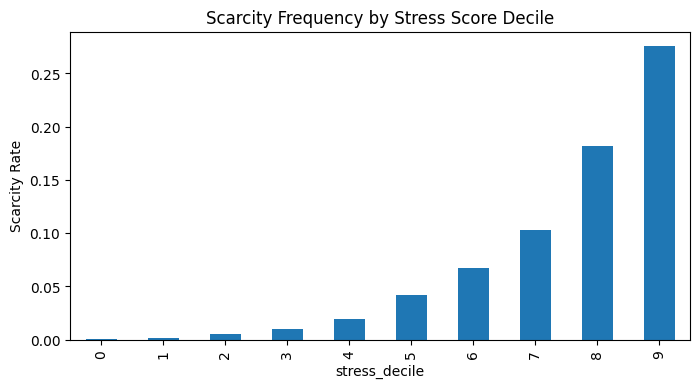

In [21]:
scarcity_rate.plot(
    kind="bar",
    figsize=(8,4)
)

plt.title(
    "Scarcity Frequency by Stress Score Decile"
)

plt.ylabel("Scarcity Rate")
plt.show()

the natural question i might ask is "okay we know that threshold definitions arent great at doing much of anything. but we do know that the variables interact. so how do we actually build a good model knowing that information? we understand that continuous physical stress indexes are more valueable, but how do we actually model them?

Scarcity ≠ demand spike

Scarcity ≈
high net load
+
low renewables
+
low wind
+
tight reserves

Adding interaction_features

In [22]:
interaction_features = [
    'ramp_x_netload',
    'ramp_x_reserve',
    'wind_x_netload',
    'renewable_x_netload',
    'imports_x_netload'
]

In [24]:
from sklearn.metrics import roc_auc_score

results = []

for feature in interaction_features:

    mask = df[feature].notna()

    y_true = df.loc[mask, "scarcity_naive"]
    y_score = df.loc[mask, feature]

    auc = roc_auc_score(y_true, y_score)

    if auc < 0.5:
        auc = 1 - auc
        direction = "negative"
    else:        
        direction = "positive"

    results.append({
        "feature": feature,
        "auc": round(auc, 3),
        "direction": direction
    })

results_df = pd.DataFrame(results).sort_values("auc", ascending=False)

print("\nInteraction Feature Predictive Power (AUC):")
print(results_df.to_string(index=False))


Interaction Feature Predictive Power (AUC):
            feature   auc direction
     wind_x_netload 0.787  negative
renewable_x_netload 0.775  negative
  imports_x_netload 0.714  positive
     ramp_x_reserve 0.638  positive
     ramp_x_netload 0.522  positive


In [25]:
baseline_features = [
    "abs_net_load_ramp",
    "net_load",
    "gen_wind",
    "renewable_share",
    "reserve_proxy_pct"
]

In [26]:
baseline_results = []

for feature in baseline_features:
    
    mask = df[feature].notna()
    
    y_true = df.loc[mask, "scarcity_naive"]
    y_score = df.loc[mask, feature]
    
    auc = roc_auc_score(y_true, y_score)
    
    if auc < 0.5:
        auc = 1 - auc
        direction = "negative"
    else:
        direction = "positive"
    
    baseline_results.append({
        "feature": feature,
        "auc": auc,
        "direction": direction
    })

baseline_df = pd.DataFrame(baseline_results).sort_values("auc", ascending=False)

print("\nBaseline Feature Predictive Power (AUC):")
print(baseline_df.to_string(index=False))


Baseline Feature Predictive Power (AUC):
          feature      auc direction
         net_load 0.830773  positive
         gen_wind 0.802965  negative
  renewable_share 0.791959  negative
reserve_proxy_pct 0.649450  negative
abs_net_load_ramp 0.520656  negative


interpretation:

1. key result summary

the interaction feature analysis shows that while interactionterms contain meaninful signal, they do not outperform the stronggest standalone system-state variables

Top standalone predictors:
- net_load → 0.83 AUC
- gen_wind → 0.80 AUC
- renewable_share → 0.79 AUC

Best interaction features:
- wind_x_netload → 0.787 AUC
- renewable_x_netload → 0.775 AUC
- imports_x_netload → 0.714 AUC
- ramp_x_reserve → 0.638 AUC
- ramp_x_netload → 0.522 AUC

2. core insight: system state dominates

the results confirm that scarcity events in the alberta power systemare primarily drive by absolute system stat conditions, rather than purely interaction-dirven dynamics. 

in particular: 
- high net load
- low wind generation
- low renewable share

are the variabel that independently capture most of the predictive signal. 

3. role of interaction features:

Interaction features do provide additional structure, but their predictive power is largely a reformulation of existing system-state information.

For example:
- wind_x_netload and renewable_x_netload perform well because they effectively encode simultaneous high demand and low renewable supply conditions.
- These features do not introduce fundamentally new information, but rather amplify existing stress conditions.

Thus, interaction terms act primarily as **nonlinear re-encodings of system state**, rather than independent drivers of scarcity.

4. ramp dynamics are conditional, not primary
Ramp-based interaction features show moderate but limited predictive power:
- ramp_x_reserve → 0.638 AUC
- ramp_x_netload → 0.522 AUC

This suggests that:
- Ramp events alone are weak predictors of scarcity
- However, ramps become more relevant when combined with already-stressed system conditions

Conclusion: Ramp dynamics are conditional amplifiers, not standalone drivers of scarcity.

5. structural interpreation of alberta market stress

these results support a state-based model of scarcity

scarcity is primarily explained by:
- net load imbalance
- renewable generation availability
- system-level supply constraints

rahter than:
- short-term volatility
- ramp events is isolation
- high-frequency fluctuations

6. modeling implications

the results suggest three important implications for predicitive modeling: 

* linear models may already capture most structure. a logistic regression using key system-state variables is likely to perform well. 
* interaction terms provide marginal gains. interactions improve representation of nonlinear structure but do no fundamentally change predictive hierarchy. 
* nonlinear models may still be required for full performance tree-based models (e.g., random forest, XGBoost) may capture conditional thresholds and nonlinear regime boundaires more effectively
